In [214]:
from shinka.utils import load_programs_to_df

path = "results/results_stlc_async_small/"
programs_df, prompts_df = load_programs_to_df(path, include_prompts=True)

Total program rows: 47
Correct program rows: 29
Total cost: $1.42
Avg cost per program: $0.03
Total prompt rows: 7
Prompts in archive: 7


In [215]:
programs_df.head()

,id,code,language,parent_id,archive_inspiration_ids,top_k_inspiration_ids,generation,timestamp,complexity,embedding,...,meta_cost,_spawned_island,_spawned_from_program_id,_spawn_island_idx,_spawn_strategy,_spawned_as_child,meta_recommendations,meta_summary,meta_scratch_pad,total_cost
0,f0252fab-763f-45a7-a1d1-d89793bde8e8,"from typing import Literal, Tuple\nimport rand...",python,NaN,[],[],0,2026-03-15 17:15:04.610419989,0.679,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
1,2ad2fd83-5e33-42d1-97bb-cbbf48066f0e,"from typing import Literal, Tuple\nimport rand...",python,f0252fab-763f-45a7-a1d1-d89793bde8e8,[],[],1,2026-03-15 17:16:10.924235106,1.000,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.032087
2,9e3937f0-9710-4557-86aa-3d4571712714,"from typing import Literal, Tuple\nimport rand...",python,f0252fab-763f-45a7-a1d1-d89793bde8e8,[2ad2fd83-5e33-42d1-97bb-cbbf48066f0e],[],7,2026-03-15 17:28:57.982111931,0.395,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.044334
3,794c88c9-cd07-48f7-850a-97ab34fd672c,"from typing import Literal, Tuple\nimport rand...",python,f0252fab-763f-45a7-a1d1-d89793bde8e8,[2ad2fd83-5e33-42d1-97bb-cbbf48066f0e],[],9,2026-03-15 17:33:16.567707062,0.406,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.058868
4,23a54f3c-451c-4ab6-b825-6ed2b43c389b,"from typing import Literal, Tuple\nimport rand...",python,f0252fab-763f-45a7-a1d1-d89793bde8e8,[2ad2fd83-5e33-42d1-97bb-cbbf48066f0e],[],10,2026-03-15 17:33:53.597270012,0.678,[],...,0.011688,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.031559


Filtered to 29 'correct' rows from 47 total.
GraphViz not available, using hierarchical layout


/Users/henry/Documents/ShinkaEvolve/.venv/lib/python3.14/site-packages/shinka/plots/plot_lineage_tree.py:384: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(
/Users/henry/Documents/ShinkaEvolve/.venv/lib/python3.14/site-packages/networkx/drawing/nx_pylab.py:1497: UserWarning: You passed a edgecolor/edgecolors ('darkred') for an unfilled marker (np.str_('x')).  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  node_collection = ax.scatter(


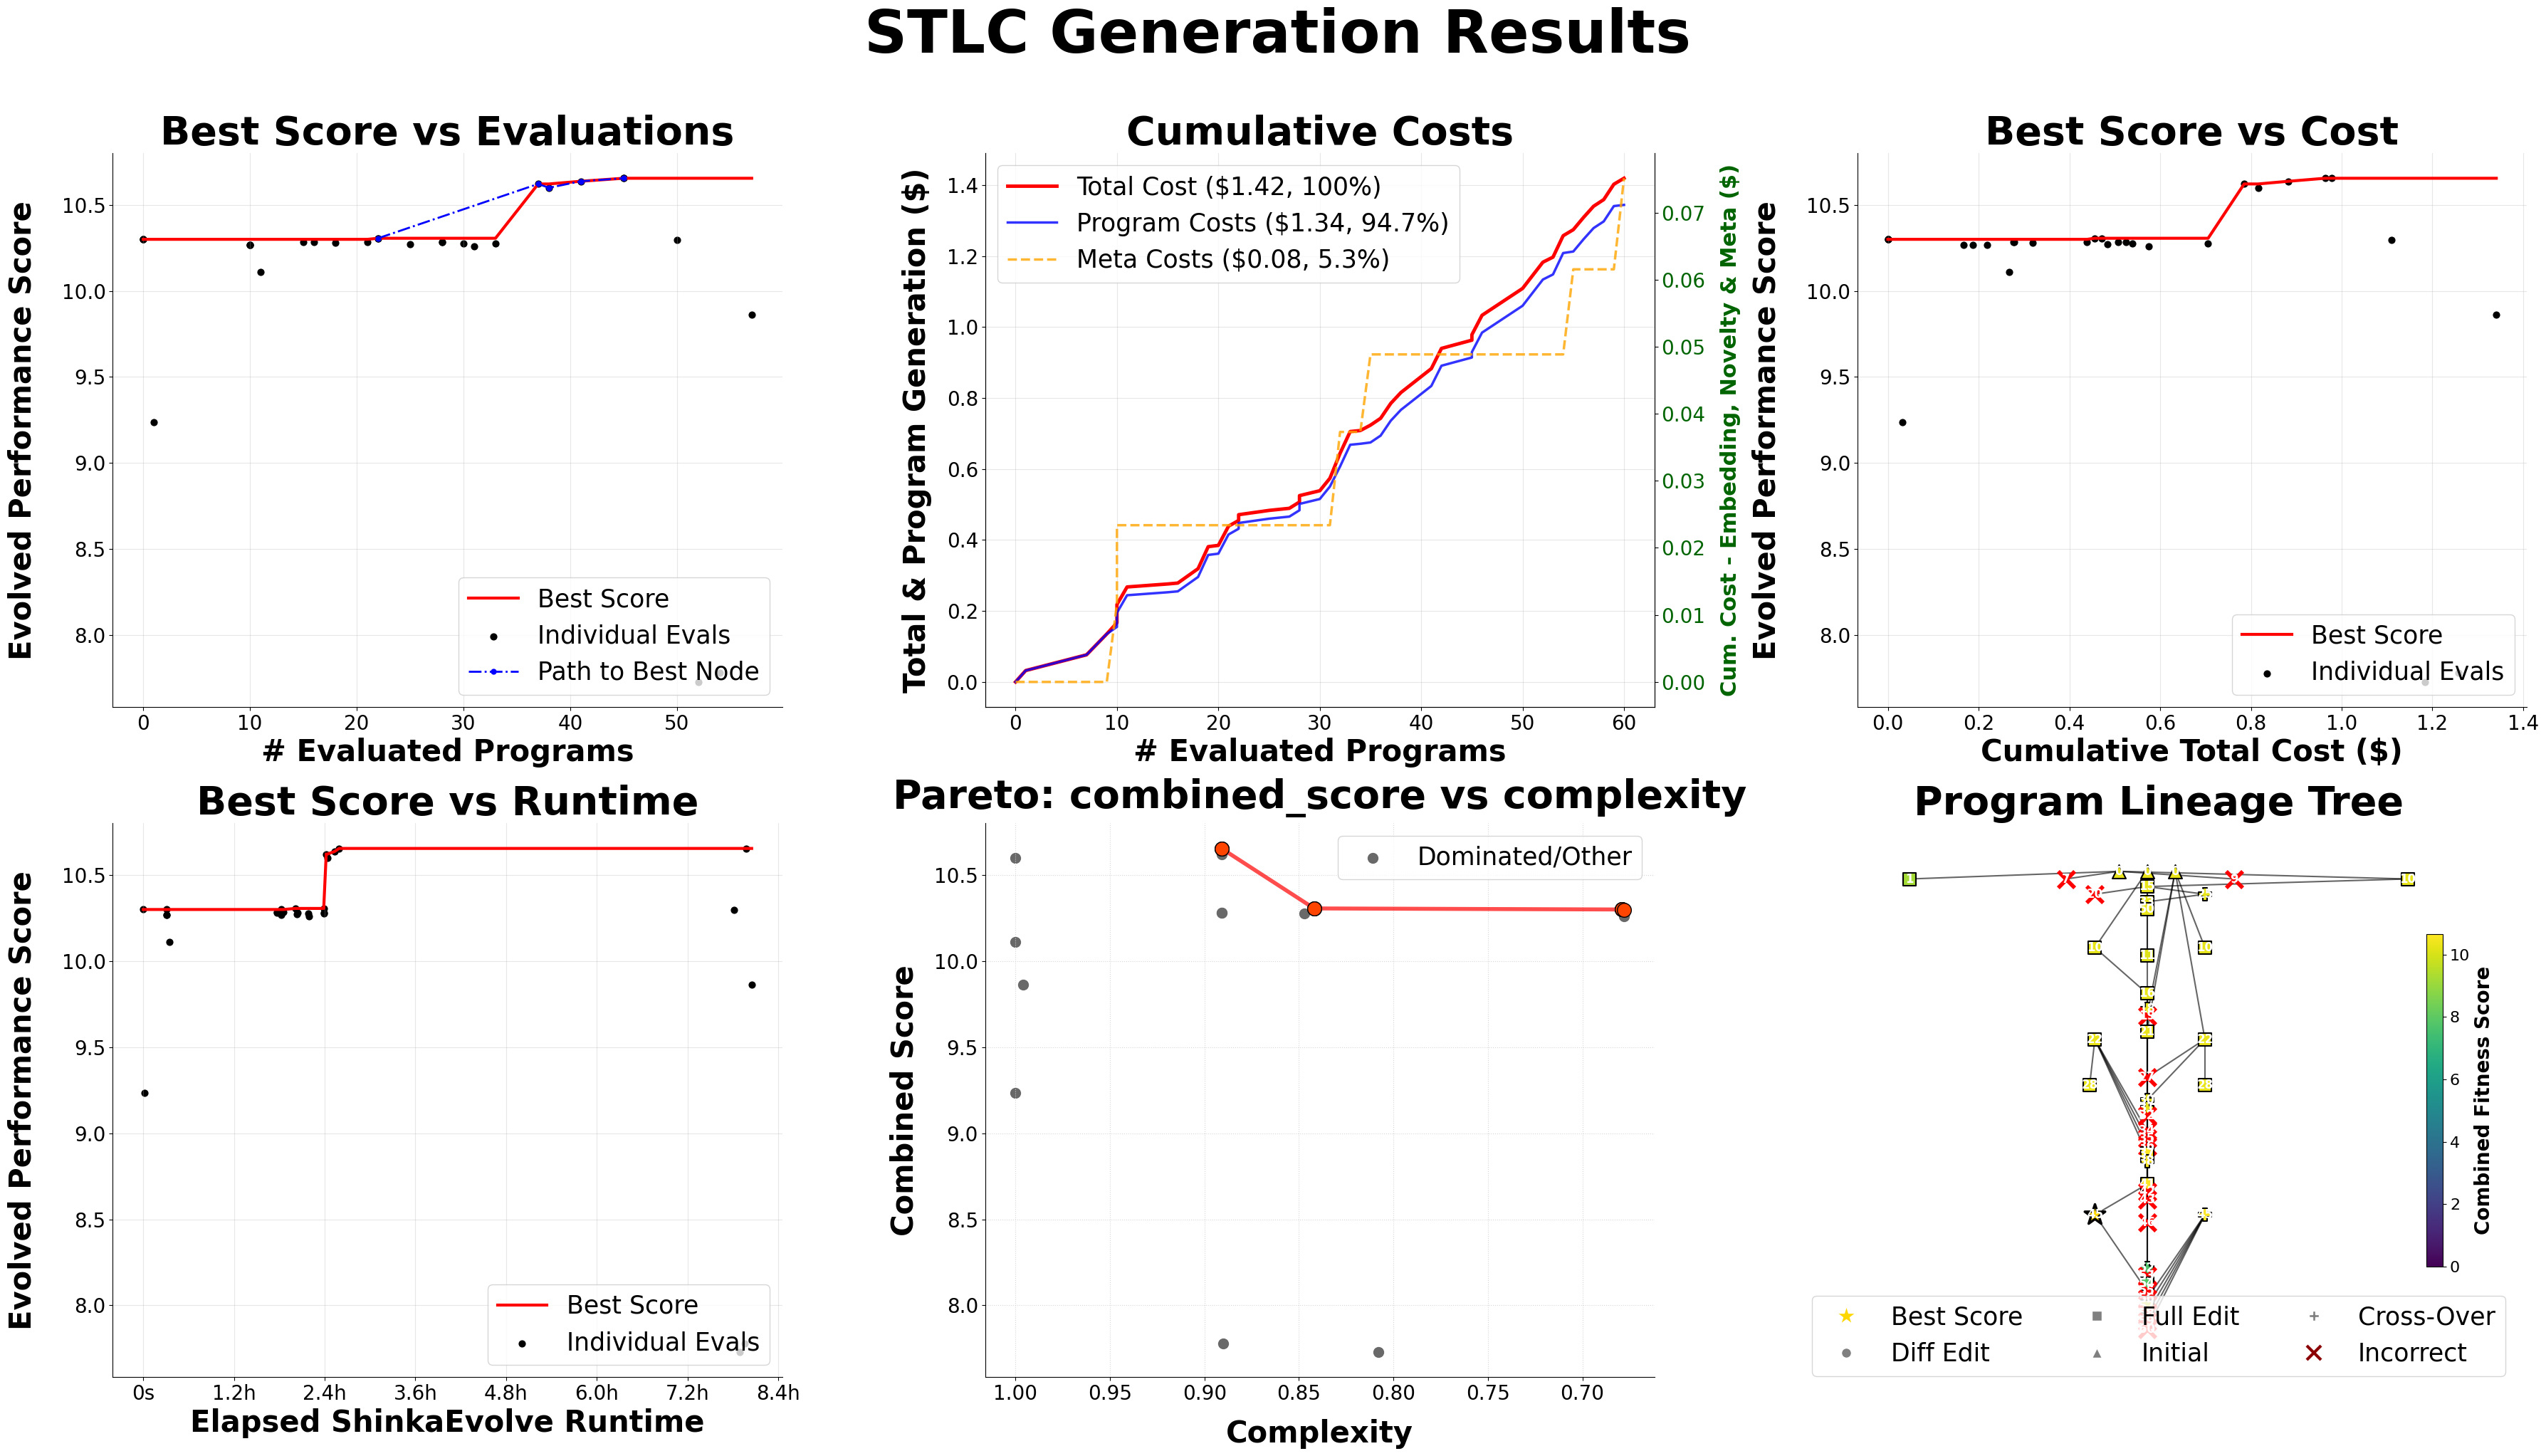

In [216]:
import matplotlib.pyplot as plt

from shinka.plots import plot_evals_performance
from shinka.plots import plot_costs
from shinka.plots import plot_cost_performance
from shinka.plots import plot_time_performance
from shinka.plots import plot_pareto_curve
from shinka.plots import plot_lineage_tree

if programs_df is None or programs_df.empty:
    raise ValueError(
        "No program data loaded. Update `path` in cell 0 to a valid results directory."
    )

fig, axs = plt.subplots(2, 3, figsize=(36, 20))
fig.suptitle("STLC Generation Results", fontsize=60, weight="bold", y=1.02)

plot_evals_performance(
    programs_df,
    title="Best Score vs Evaluations",
    fig=fig,
    ax=axs[0, 0],
    annotate=False,
    show_cost=False,
)

plot_costs(
    programs_df,
    title="Cumulative Costs",
    fig=fig,
    ax=axs[0, 1],
)

plot_cost_performance(
    programs_df,
    title="Best Score vs Cost",
    fig=fig,
    ax=axs[0, 2],
)

plot_time_performance(
    programs_df,
    title="Best Score vs Runtime",
    fig=fig,
    ax=axs[1, 0],
)

# Pick a Pareto pair that usually exists in Shinka results.
if "loc" in programs_df.columns:
    pareto_x, pareto_y = "loc", "combined_score"
    x_maximize, y_maximize = False, True
elif "complexity" in programs_df.columns:
    pareto_x, pareto_y = "complexity", "combined_score"
    x_maximize, y_maximize = False, True
elif "total_cost" in programs_df.columns:
    pareto_x, pareto_y = "total_cost", "combined_score"
    x_maximize, y_maximize = False, True
else:
    pareto_x, pareto_y = "generation", "combined_score"
    x_maximize, y_maximize = True, True

plot_pareto_curve(
    programs_df,
    x_variable=pareto_x,
    y_variable=pareto_y,
    x_maximize=x_maximize,
    y_maximize=y_maximize,
    title=f"Pareto: {pareto_y} vs {pareto_x}",
    fig=fig,
    ax=axs[1, 1],
    annotate=False,
)

plot_lineage_tree(
    programs_df,
    title="Program Lineage Tree",
    fig=fig,
    ax=axs[1, 2],
)

plt.tight_layout()
plt.show()
